In [29]:
from pathlib import Path

# ===== Paths =====
DATA_DIR = Path("/home/danila/networks/data")
TRAIN_CSV = DATA_DIR / "train_split.csv"
VALID_CSV = DATA_DIR / "valid_split.csv"

# embeddings
TEXT_EMB_DIR = DATA_DIR / "embeddings" / "text_gte_base_whisper_large_v3_cls128_v2"

RUN_DIR = DATA_DIR / "runs" / "text_only_gte_base_whisper_large_v3_cls128_v2"
RUN_DIR.mkdir(parents=True, exist_ok=True)

CKPT_BEST_LOSS = RUN_DIR / "best_loss.pt"
CKPT_BEST_CORR = RUN_DIR / "best_corr.pt"
HIST_PATH = RUN_DIR / "history.json"
NORM_PATH = RUN_DIR / "norm_params.npz"

# ===== Task =====
EMOTIONS = ["Admiration","Amusement","Determination","Empathic Pain","Excitement","Joy"]
NUM_TARGETS = 6
ID_WIDTH = 5

# ===== Preprocessing =====
USE_PCA = True
PCA_DIM = 512        # 256/384/512

# ===== Training =====
DEVICE = "cuda"
SEED = 42

BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = True

HIDDEN = 512
DROPOUT = 0.4

LR = 5e-4
WEIGHT_DECAY = 5e-2
MAX_EPOCHS = 80
PATIENCE = 10
MIN_DELTA_LOSS = 1e-4
MIN_DELTA_CORR = 1e-4

USE_AMP = True
GRAD_CLIP_NORM = 1.0

# ===== Loss =====
LAMBDA_PEARSON = 0.2
LAMBDA_SMOOTHL1 = 1.0
PEARSON_ACCUM_STEPS = 4

# ===== Warmup & schedule =====
WARMUP_FRAC = 0.05

In [30]:
import os, json, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print("CUDA:", torch.cuda.is_available(), "| DEVICE:", DEVICE)

CUDA: True | DEVICE: cuda


In [31]:
def load_embedding_npz(path: Path) -> np.ndarray:
    d = np.load(path, allow_pickle=False)
    # key: embedding
    emb = d["embedding"]
    return emb.astype(np.float32)  # (D,)

def load_split_with_embeddings(csv_path: Path, emb_dir: Path):
    df = pd.read_csv(csv_path, dtype={"Filename": str})
    df["Filename"] = df["Filename"].str.zfill(ID_WIDTH)

    X_list, y_list, ids_ok = [], [], []
    missing = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Load {csv_path.name}"):
        vid = row["Filename"]
        p = emb_dir / f"{vid}.npz"
        if not p.exists():
            missing.append({"video_id": vid, "reason": "emb_missing"})
            continue
        try:
            x = load_embedding_npz(p)  # (D,)
            y = np.array([row[e] for e in EMOTIONS], dtype=np.float32)  # (6,)
            X_list.append(x)
            y_list.append(y)
            ids_ok.append(vid)
        except Exception as e:
            missing.append({"video_id": vid, "reason": f"read_error:{repr(e)}"})

    X = np.stack(X_list, axis=0) if X_list else np.zeros((0,0), dtype=np.float32)
    Y = np.stack(y_list, axis=0) if y_list else np.zeros((0, NUM_TARGETS), dtype=np.float32)
    miss_df = pd.DataFrame(missing)
    return X, Y, ids_ok, miss_df

X_tr_raw, Y_tr_raw, ids_tr, miss_tr = load_split_with_embeddings(TRAIN_CSV, TEXT_EMB_DIR)
X_va_raw, Y_va_raw, ids_va, miss_va = load_split_with_embeddings(VALID_CSV, TEXT_EMB_DIR)

print("Train loaded:", X_tr_raw.shape, Y_tr_raw.shape, "missing:", len(miss_tr))
print("Val   loaded:", X_va_raw.shape, Y_va_raw.shape, "missing:", len(miss_va))

pd.concat([miss_tr.assign(split="train"), miss_va.assign(split="val")]).to_csv(RUN_DIR / "missing_embeddings.csv", index=False)

Load valid_split.csv: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [00:01<00:00, 2601.95it/s]

Train loaded: (8072, 768) (8072, 6) missing: 0
Val   loaded: (4588, 768) (4588, 6) missing: 0


In [32]:
def load_embedding_npz(path: Path) -> np.ndarray:
    d = np.load(path, allow_pickle=False)
    # key: embedding
    emb = d["embedding"]
    return emb.astype(np.float32)  # (D,)

def load_split_with_embeddings(csv_path: Path, emb_dir: Path):
    df = pd.read_csv(csv_path, dtype={"Filename": str})
    df["Filename"] = df["Filename"].str.zfill(ID_WIDTH)

    X_list, y_list, ids_ok = [], [], []
    missing = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Load {csv_path.name}"):
        vid = row["Filename"]
        p = emb_dir / f"{vid}.npz"
        if not p.exists():
            missing.append({"video_id": vid, "reason": "emb_missing"})
            continue
        try:
            x = load_embedding_npz(p)  # (D,)
            y = np.array([row[e] for e in EMOTIONS], dtype=np.float32)  # (6,)
            X_list.append(x)
            y_list.append(y)
            ids_ok.append(vid)
        except Exception as e:
            missing.append({"video_id": vid, "reason": f"read_error:{repr(e)}"})

    X = np.stack(X_list, axis=0) if X_list else np.zeros((0,0), dtype=np.float32)
    Y = np.stack(y_list, axis=0) if y_list else np.zeros((0, NUM_TARGETS), dtype=np.float32)
    miss_df = pd.DataFrame(missing)
    return X, Y, ids_ok, miss_df

X_tr_raw, Y_tr_raw, ids_tr, miss_tr = load_split_with_embeddings(TRAIN_CSV, TEXT_EMB_DIR)
X_va_raw, Y_va_raw, ids_va, miss_va = load_split_with_embeddings(VALID_CSV, TEXT_EMB_DIR)

print("Train loaded:", X_tr_raw.shape, Y_tr_raw.shape, "missing:", len(miss_tr))
print("Val   loaded:", X_va_raw.shape, Y_va_raw.shape, "missing:", len(miss_va))

pd.concat([miss_tr.assign(split="train"), miss_va.assign(split="val")]).to_csv(RUN_DIR / "missing_embeddings.csv", index=False)

Load valid_split.csv: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4588/4588 [00:01<00:00, 2631.51it/s]

Train loaded: (8072, 768) (8072, 6) missing: 0
Val   loaded: (4588, 768) (4588, 6) missing: 0


In [33]:
# ---- target normalization (train only) ----
y_mean = Y_tr_raw.mean(axis=0)
y_std  = np.clip(Y_tr_raw.std(axis=0), 1e-3, None)

Y_tr = (Y_tr_raw - y_mean[None,:]) / y_std[None,:]
Y_va = (Y_va_raw - y_mean[None,:]) / y_std[None,:]

# ---- feature scaling (train only) ----
scaler = StandardScaler(with_mean=True, with_std=True)
X_tr = scaler.fit_transform(X_tr_raw)
X_va = scaler.transform(X_va_raw)

# ---- optional PCA ----
pca = None
if USE_PCA:
    pca = PCA(n_components=PCA_DIM, random_state=SEED)
    X_tr = pca.fit_transform(X_tr)
    X_va = pca.transform(X_va)
    print("PCA enabled:", PCA_DIM, "| X_tr:", X_tr.shape)

np.savez(
    NORM_PATH,
    y_mean=y_mean.astype(np.float32),
    y_std=y_std.astype(np.float32),
    x_mean=scaler.mean_.astype(np.float32),
    x_scale=scaler.scale_.astype(np.float32),
    use_pca=np.array([USE_PCA], dtype=np.int32),
    pca_dim=np.array([PCA_DIM], dtype=np.int32),
    pca_components=(pca.components_.astype(np.float32) if pca is not None else np.zeros((0,0), np.float32)),
    pca_mean=(pca.mean_.astype(np.float32) if pca is not None else np.zeros((0,), np.float32)),
)
print("Saved norm params:", NORM_PATH)

PCA enabled: 512 | X_tr: (8072, 512)
Saved norm params: /home/danila/networks/data/runs/text_only_gte_base_whisper_large_v3_cls128_v2/norm_params.npz


In [34]:
def pearson_per_dim_np(P: np.ndarray, Y: np.ndarray, eps: float = 1e-8):
    corrs = []
    for k in range(P.shape[1]):
        x = P[:,k].astype(np.float64); y = Y[:,k].astype(np.float64)
        vx = x - x.mean(); vy = y - y.mean()
        denom = (np.sqrt((vx*vx).sum()) * np.sqrt((vy*vy).sum()) + eps)
        corrs.append(float((vx*vy).sum() / denom))
    return float(np.mean(corrs)), corrs

ridge = Ridge(alpha=10.0, random_state=SEED) # alpha=100,
ridge.fit(X_tr, Y_tr)
P_va_r = ridge.predict(X_va)
P_tr_r = ridge.predict(X_tr)

mean_corr_va, per_va = pearson_per_dim_np(P_va_r, Y_va)
mean_corr_tr, per_tr = pearson_per_dim_np(P_tr_r, Y_tr)

print("Ridge mean corr | train:", mean_corr_tr, "| val:", mean_corr_va)
for e, c in zip(EMOTIONS, per_va):
    print(f"{e:14s}: {c:.4f}")

Ridge mean corr | train: 0.5124956181220875 | val: 0.36030831832295673
Admiration    : 0.4606
Amusement     : 0.3412
Determination : 0.3361
Empathic Pain : 0.4051
Excitement    : 0.3269
Joy           : 0.2919


In [35]:
from torch.utils.data import TensorDataset, DataLoader

Xtr_t = torch.tensor(X_tr, dtype=torch.float32)
Ytr_t = torch.tensor(Y_tr, dtype=torch.float32)
Xva_t = torch.tensor(X_va, dtype=torch.float32)
Yva_t = torch.tensor(Y_va, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(Xtr_t, Ytr_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

valid_loader = DataLoader(
    TensorDataset(Xva_t, Yva_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False
)

print("Batches train:", len(train_loader), "val:", len(valid_loader))

Batches train: 64 val: 36


In [36]:
def pearson_corr_torch(preds: torch.Tensor, targets: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    vx = preds - preds.mean(0)
    vy = targets - targets.mean(0)
    corr = (vx * vy).sum(0) / (torch.sqrt((vx**2).sum(0) * (vy**2).sum(0)) + eps)
    return corr.mean()

smooth_loss_fn = nn.SmoothL1Loss(beta=0.2)

def combined_loss(P: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    # P/Y: [N,6]
    loss_s = smooth_loss_fn(P, Y)
    loss_p = 1.0 - pearson_corr_torch(P, Y)
    return LAMBDA_SMOOTHL1 * loss_s + LAMBDA_PEARSON * loss_p

In [37]:
class TextMLP(nn.Module):
    def __init__(self, din: int, hidden: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(din),
            nn.Linear(din, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, NUM_TARGETS),
        )

    def forward(self, x):
        return self.net(x)

DIN = X_tr.shape[1]
model = TextMLP(DIN, HIDDEN, DROPOUT).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))

# cosine + warmup по шагам optimizer step'ов (учитываем flush каждые ACCUM_STEPS)
steps_per_epoch = math.ceil(len(train_loader) / PEARSON_ACCUM_STEPS)
total_steps = MAX_EPOCHS * steps_per_epoch
warmup_steps = int(WARMUP_FRAC * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print(model)

TextMLP(
  (net): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=6, bias=True)
  )
)


/tmp/ipykernel_154997/2413271561.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and USE_AMP))


In [38]:
@torch.inference_mode()
def eval_epoch(model, loader):
    model.eval()
    Ps, Ys = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        p = model(xb)
        Ps.append(p.detach().float().cpu())
        Ys.append(yb.detach().float().cpu())
    P = torch.cat(Ps, dim=0)
    Y = torch.cat(Ys, dim=0)
    loss = combined_loss(P, Y).item()
    corr = pearson_corr_torch(P, Y).item()
    return {"loss": float(loss), "corr": float(corr)}

def train_epoch(model, loader):
    model.train()
    buf_p, buf_y = [], []
    buf_count = 0
    group_losses = []

    # by epoch
    all_p, all_y = [], []

    for step, (xb, yb) in enumerate(tqdm(loader, desc="train", leave=False), start=1):
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            p = model(xb)

        all_p.append(p.detach().float().cpu())
        all_y.append(yb.detach().float().cpu())

        buf_p.append(p)
        buf_y.append(yb)
        buf_count += 1

        flush = (buf_count >= PEARSON_ACCUM_STEPS) or (step == len(loader))
        if not flush:
            continue

        optimizer.zero_grad(set_to_none=True)

        P = torch.cat(buf_p, dim=0)
        Y = torch.cat(buf_y, dim=0)

        with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
            loss = combined_loss(P, Y)

        if torch.isfinite(loss):
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            group_losses.append(float(loss.item()))

        buf_p, buf_y, buf_count = [], [], 0

    P_all = torch.cat(all_p, dim=0)
    Y_all = torch.cat(all_y, dim=0)

    train_loss = float(np.mean(group_losses)) if group_losses else float("nan")
    train_corr = float(pearson_corr_torch(P_all, Y_all).item())
    return {"loss": train_loss, "corr": train_corr}

In [39]:
history = {"train_loss": [], "train_corr": [], "val_loss": [], "val_corr": [], "lr": []}

best_val_loss = float("inf")
#best_val_corr = -1e9
#bad_epochs = 0
best_epoch_loss = -1
best_epoch_corr = -1

BEST_METRIC = "corr"      # maximize
PATIENCE = 15
MIN_DELTA_CORR = 1e-4

best_val_corr = -1e9
best_epoch = -1
bad_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr = train_epoch(model, train_loader)
    va = eval_epoch(model, valid_loader)

    lr_now = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(tr["loss"])
    history["train_corr"].append(tr["corr"])
    history["val_loss"].append(va["loss"])
    history["val_corr"].append(va["corr"])
    history["lr"].append(lr_now)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {tr['loss']:.4f} corr {tr['corr']:.4f} | "
        f"val loss {va['loss']:.4f} corr {va['corr']:.4f} | "
        f"lr {lr_now:.2e}"
    )

    improved = (va["corr"] - best_val_corr) > MIN_DELTA_CORR
    if improved:
        best_val_corr = va["corr"]
        best_epoch = epoch
        bad_epochs = 0
        torch.save(
            {"epoch": epoch, "model_state": model.state_dict(), "best_val_corr": best_val_corr},
            CKPT_BEST_CORR
        )
        with open(HIST_PATH, "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2)
        print(f"  ✅ Saved best-by-corr: epoch={epoch}, val_corr={best_val_corr:.4f}")
    else:
        bad_epochs += 1
        print(f"  ⏳ No val corr improvement: {bad_epochs}/{PATIENCE}")

    if bad_epochs >= PATIENCE:
        print(f"🛑 Early stopping by corr. Best epoch={best_epoch}, best val corr={best_val_corr:.4f}")
        break

print("Best val loss:", best_val_loss, "at epoch", best_epoch_loss)
print("Best val corr:", best_val_corr, "at epoch", best_epoch_corr)
print("Saved:", CKPT_BEST_LOSS, CKPT_BEST_CORR)

train:   0%|                                                                                                                                                                          | 0/64 [00:00<?, ?it/s]/tmp/ipykernel_154997/3442183326.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
/tmp/ipykernel_154997/3442183326.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda" and USE_AMP)):
                                                                                                                                                                                                             

Epoch 001 | train loss 0.8457 corr 0.0245 | val loss 0.7623 corr 0.0863 | lr 1.25e-04
  ✅ Saved best-by-corr: epoch=1, val_corr=0.0863


Epoch 002 | train loss 0.7669 corr 0.1302 | val loss 0.6493 corr 0.2309 | lr 2.50e-04
  ✅ Saved best-by-corr: epoch=2, val_corr=0.2309


Epoch 003 | train loss 0.6596 corr 0.2911 | val loss 0.5661 corr 0.3412 | lr 3.75e-04
  ✅ Saved best-by-corr: epoch=3, val_corr=0.3412


Epoch 004 | train loss 0.6037 corr 0.3965 | val loss 0.5471 corr 0.3831 | lr 5.00e-04
  ✅ Saved best-by-corr: epoch=4, val_corr=0.3831


...

Epoch 067 | train loss 0.2922 corr 0.8166 | val loss 0.5307 corr 0.4519 | lr 3.52e-05
  ⏳ No val corr improvement: 11/15


Epoch 068 | train loss 0.2905 corr 0.8187 | val loss 0.5309 corr 0.4520 | lr 3.01e-05
  ⏳ No val corr improvement: 12/15


Epoch 069 | train loss 0.2892 corr 0.8188 | val loss 0.5310 corr 0.4520 | lr 2.54e-05
  ⏳ No val corr improvement: 13/15


Epoch 070 | train loss 0.2906 corr 0.8171 | val loss 0.5311 corr 0.4521 | lr 2.11e-05
  ⏳ No val corr improvement: 14/15


Epoch 071 | train loss 0.2893 corr 0.8185 | val loss 0.5311 corr 0.4521 | lr 1.71e-05
  ⏳ No val corr improvement: 15/15
🛑 Early stopping by corr. Best epoch=56, best val corr=0.4521
Best val loss: inf at epoch -1
Best val corr: 0.4521426856517792 at epoch -1
Saved: /home/danila/networks/data/runs/text_only_gte_base_whisper_large_v3_cls128_v2/best_loss.pt /home/danila/networks/data/runs/text_only_gte_base_whisper_large_v3_cls128_v2/best_corr.pt


In [40]:
def per_emotion_corr_np(P: np.ndarray, Y: np.ndarray, eps: float = 1e-8):
    out = {}
    for i, name in enumerate(EMOTIONS):
        x = P[:, i].astype(np.float64)
        y = Y[:, i].astype(np.float64)
        vx = x - x.mean(); vy = y - y.mean()
        out[name] = float((vx*vy).sum() / (np.sqrt((vx*vx).sum()* (vy*vy).sum()) + eps))
    return out

# load best-by-corr
ckpt = torch.load(CKPT_BEST_CORR, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Loaded best-by-corr epoch:", ckpt["epoch"], "val_corr:", ckpt["best_val_corr"])

# collect preds on val
@torch.inference_mode()
def collect_preds(model, loader):
    Ps, Ys = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        p = model(xb).detach().float().cpu().numpy()
        Ps.append(p)
        Ys.append(yb.numpy())
    return np.concatenate(Ps, axis=0), np.concatenate(Ys, axis=0)

P_va, Y_va_norm = collect_preds(model, valid_loader)

mean_corr, _ = pearson_per_dim_np(P_va, Y_va_norm)
print("Val mean corr (normalized targets):", mean_corr)

per = per_emotion_corr_np(P_va, Y_va_norm)
for e in EMOTIONS:
    print(f"{e:14s}: {per[e]:.4f}")

Loaded best-by-corr epoch: 56 val_corr: 0.4521426856517792
Val mean corr (normalized targets): 0.45214269202482593
Admiration    : 0.5250
Amusement     : 0.4422
Determination : 0.4214
Empathic Pain : 0.5253
Excitement    : 0.4248
Joy           : 0.3742


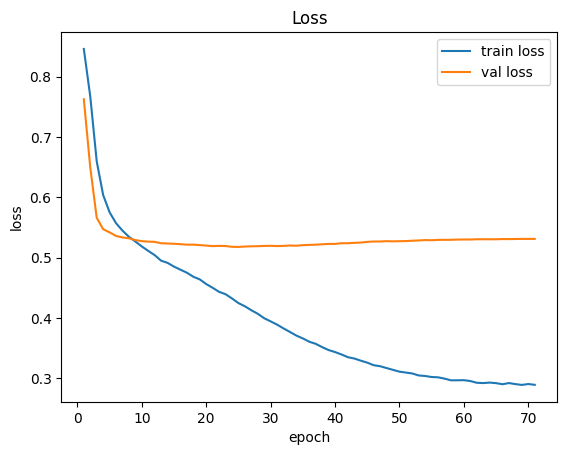

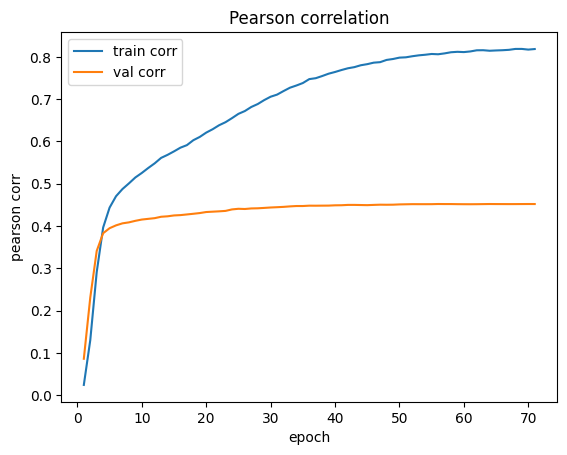

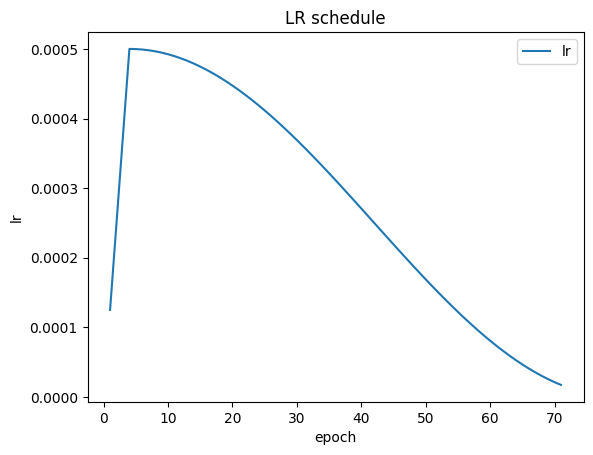

In [41]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss")
plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["train_corr"], label="train corr")
plt.plot(epochs, history["val_corr"], label="val corr")
plt.xlabel("epoch"); plt.ylabel("pearson corr")
plt.title("Pearson correlation")
plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["lr"], label="lr")
plt.xlabel("epoch"); plt.ylabel("lr")
plt.title("LR schedule")
plt.legend(); plt.show()